## Non-standard primordial power spectrum (wavepacket oscillation)

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
import math
from camb import model, initialpower
print('Using CAMB %s'%(camb.__version__))

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Using CAMB 1.5.9 installed at /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/CAMB/camb


<Figure size 640x480 with 0 Axes>

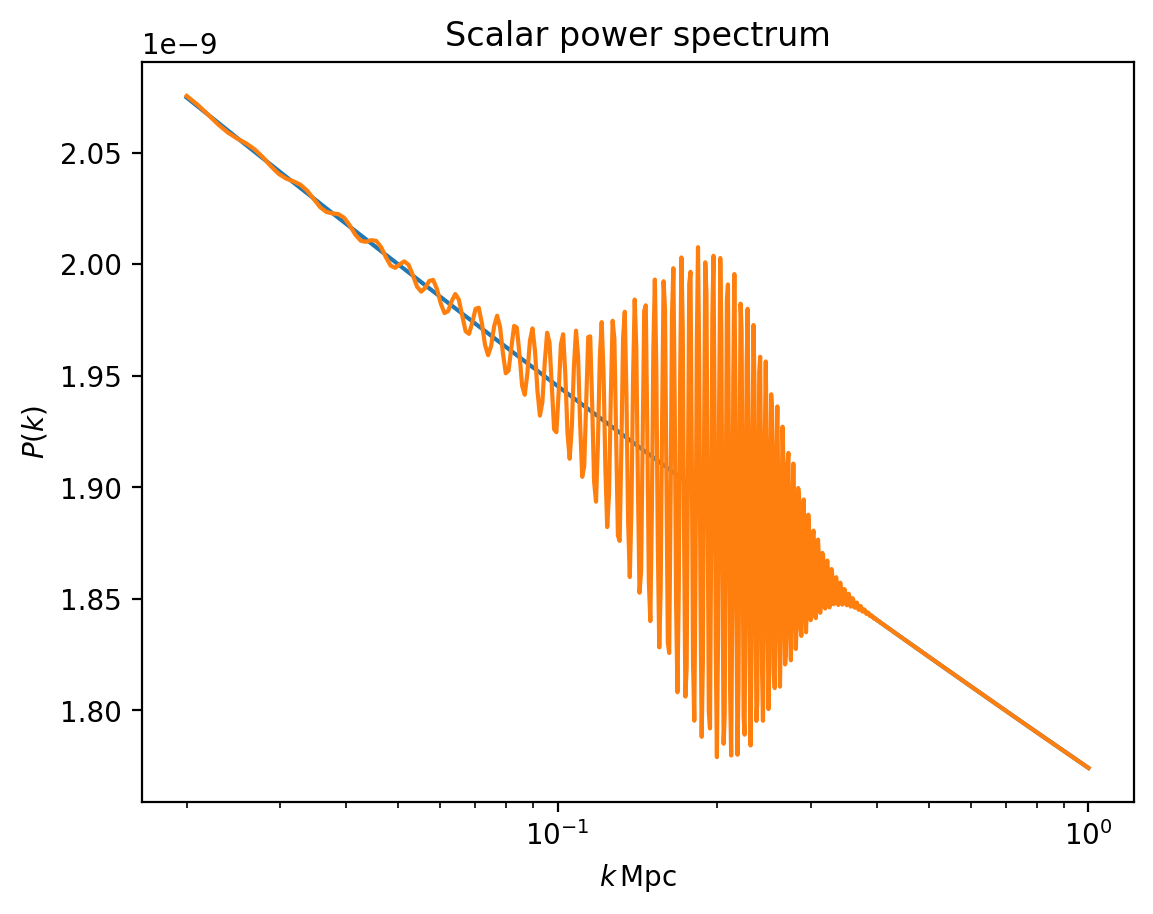

<Figure size 640x480 with 0 Axes>

In [2]:
from CMBFeatureNet import PK
freq = 1000
ks = np.linspace(0.02,1,1000)
pk1 = 2e-9*(ks/0.05)**(0.96-1)
pk2 = PK(ks,2e-9, 0.96,0.0599,freq, 0.08, 0.2,0)
plt.semilogx(ks,pk1)
plt.semilogx(ks,pk2)
plt.ylabel('$P(k)$')
plt.xlabel(r'$k\, {\rm Mpc}$');
plt.title('Scalar power spectrum')
plt.figure()

In [3]:
#Planck TT data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT1 = data_Planck[:, 2]
sdl_Planck_TT2 = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

#Planck TE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE1 = data_Planck[:, 2]
sdl_Planck_TE2 = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

#Planck EE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE1 = data_Planck[:, 2]
sdl_Planck_EE2 = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [4]:
Tcmb = 2.7255
CF = (Tcmb*10**6)**2

#Converting the c_ls^TT to Dls
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(CF*l[i]*l[i]+1)*DlTT[i] for i in range(len(l))]
    return ClTT

In [ ]:
#Read Covariance matrix
base_pathCV = "./simulated_data/simulated_cov_matrices/"
cov_matx_dltt_mcmc = np.loadtxt(base_pathCV +'/dlstt_cov_matx(mcmc).csv', delimiter=",")
cov_matx_dlte_mcmc = np.loadtxt(base_pathCV +'/dlste_cov_matx(mcmc).csv', delimiter=",")
cov_matx_dlee_mcmc = np.loadtxt(base_pathCV +'/dlsee_cov_matx(mcmc).csv', delimiter=",")

In [6]:
from CMBFeatureNet import generate_camb_power_spectra
Power_spectra = generate_camb_power_spectra(67.4, 0.02237, 0.1200, 0.06, 0, tau=0.0544,  
                    As=2.1e-9, ns=0.9649, halofit_version='mead', lmax=2507, custom_PK=True, 
                    amp=0.0599, freq=freq, wid=0.08, centre=0.2, phase=0)

<class 'functions.simulate_data.CMBPowerSpectra'>


In [7]:
from CMBFeatureNet import add_noise_spectrum
seed0 = 314100
dlstt_mcmc = add_noise_spectrum(Power_spectra.tt, cov_matx_dltt_mcmc, seed0)
dlste_mcmc = add_noise_spectrum(Power_spectra.te, cov_matx_dlte_mcmc, seed0)
dlsee_mcmc = add_noise_spectrum(Power_spectra.ee, cov_matx_dlee_mcmc, seed0)

dlstt = Power_spectra.tt[:len(round_ls_Pl_TT)]
dlste = Power_spectra.te[:len(round_ls_Pl_TE)]
dlsee = Power_spectra.ee[:len(round_ls_Pl_EE)]

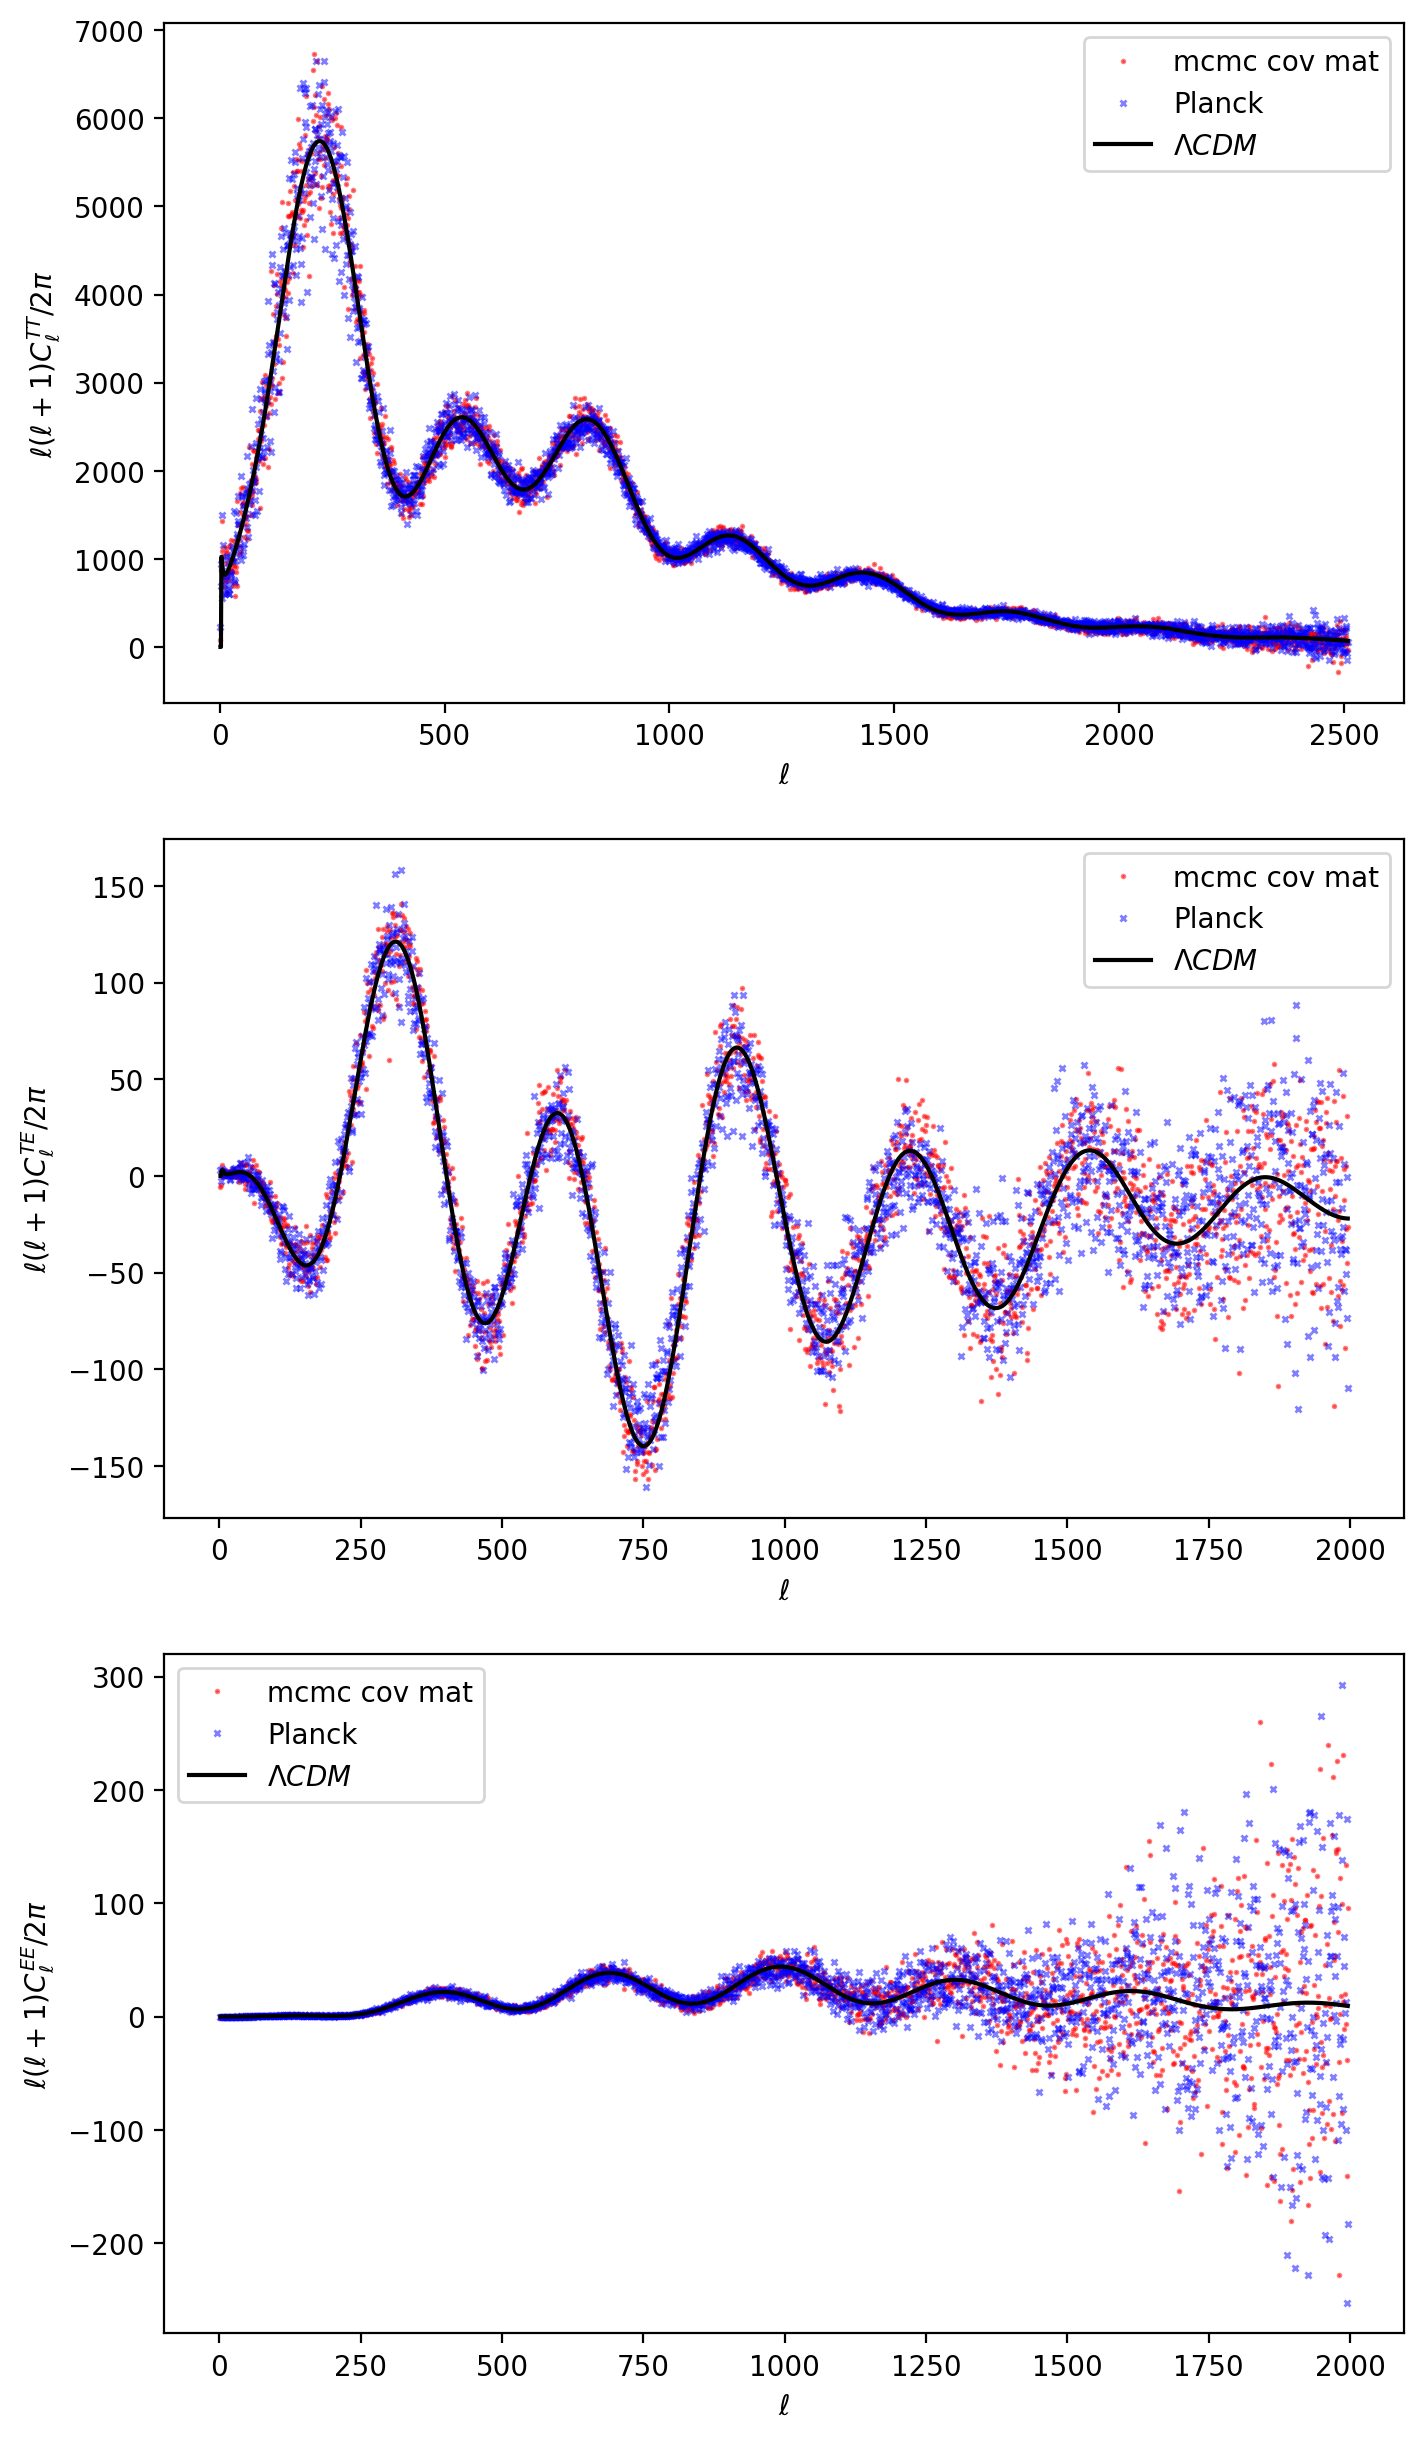

In [8]:
fig, ax = plt.subplots(3,1, figsize = (8,15))

ax[0].plot(round_ls_Pl_TT,dlstt_mcmc, marker='o', color='red', label='mcmc cov mat', linestyle='None', markersize=1, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT,dl_Planck_TT, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT, dlstt, color='black', label='$\Lambda CDM$', linestyle='-')
ax[0].set_xlabel('$\ell$')
ax[0].set_ylabel('$\ell(\ell+1)C_{\ell}^{TT}/2\pi$')
ax[0].legend()

ax[1].plot(round_ls_Pl_TE,dlste_mcmc, marker='o', color='red', label='mcmc cov mat', linestyle='None', markersize=1, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE,dl_Planck_TE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE, dlste, color='black', label='$\Lambda CDM$', linestyle='-')
ax[1].set_xlabel('$\ell$')
ax[1].set_ylabel('$\ell(\ell+1)C_{\ell}^{TE}/2\pi$')
ax[1].legend()

ax[2].plot(round_ls_Pl_EE,dlsee_mcmc, marker='o', color='red', label='mcmc cov mat', linestyle='None', markersize=1, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE,dl_Planck_EE, marker='x', color='blue', label='Planck', linestyle='None', markersize=2, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE, dlsee, color='black', label='$\Lambda CDM$', linestyle='-')
ax[2].set_xlabel('$\ell$')
ax[2].set_ylabel('$\ell(\ell+1)C_{\ell}^{EE}/2\pi$')
ax[2].legend()

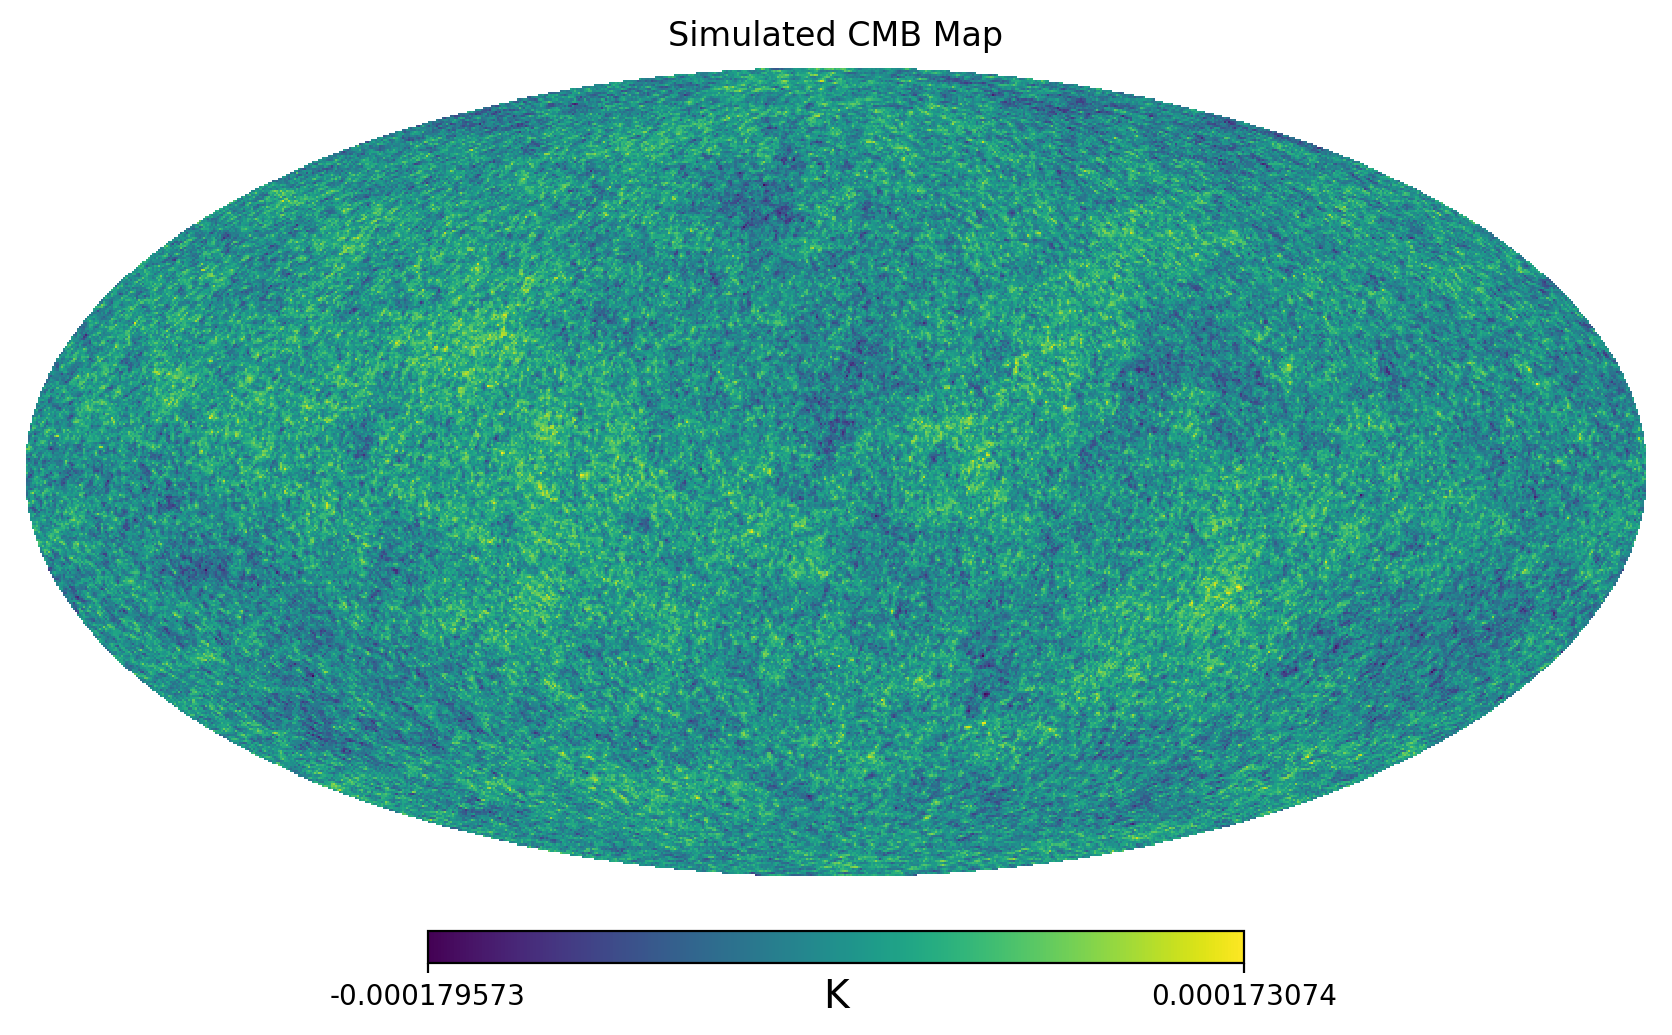

In [ ]:
from CMBFeatureNet import generate_cmb_temperature_map
#Generate and visualize the CMB map
cmb_map = generate_cmb_temperature_map(Cls(round_ls_Pl_TT,dlstt_mcmc), nside=2048)